# 🖥️ GPU vs CPU — Data Processing & Analytics Benchmark

Notebook ini adalah experiment langsung untuk membandingkan performa **pandas (CPU)** vs **cuDF/RAPIDS (GPU)**  
pada berbagai operasi data analytics yang umum digunakan di dunia nyata.

---

## 📋 Daftar Experiment

| # | Experiment | Apa yang diuji |
|---|---|---|
| 0 | Setup & Deteksi GPU | Cek environment, load data |
| 1 | Duplikasi Data | 1K → 1 juta baris |
| 2 | I/O Benchmark | Read CSV vs Parquet |
| 3 | Filter & Selection | WHERE clause |
| 4 | GroupBy & Aggregation | GROUP BY + multi agregasi |
| 5 | Sort | ORDER BY single & multi kolom |
| 6 | Join / Merge | INNER JOIN & LEFT JOIN |
| 7 | Vectorized Feature Eng | Kalkulasi kolom baru |
| 8 | String Operations | str.contains, upper, replace |
| 9 | Rolling Window | Moving average time-series |
| 10 | End-to-End Pipeline | ETL lengkap |
| 11 | Visualisasi & Load Test | Chart + render benchmark |
| 12 | Ringkasan & Kesimpulan | Summary semua hasil |

---

## ⚙️ Requirements

```bash
# Cek versi CUDA
nvidia-smi

# Install RAPIDS (sesuaikan dengan versi CUDA kamu)
pip install cudf-cu12 cupy-cuda12x   # untuk CUDA 12.x
# pip install cudf-cu11 cupy-cuda11x  # untuk CUDA 11.x

# Install dependencies lain
pip install pandas numpy matplotlib seaborn pyarrow jupyter
```

> **Note:** Jika GPU tidak tersedia, semua cell GPU di-skip otomatis dan hanya CPU yang dijalankan.

---
## 🔧 Cell 0 — Setup & Deteksi GPU

In [3]:
# !pip install pandas numpy matplotlib seaborn pyarrow jupyter

In [4]:
# ================================================================
# CELL 0.1 — Import library & deteksi GPU
# ================================================================
import time
import os
import warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Deteksi GPU ──────────────────────────────────────────────────
GPU_AVAILABLE = False
cudf = None
cp   = None

try:
    import cudf as cudf
    import cupy as cp
    GPU_AVAILABLE = True
    print('✅ cuDF (GPU) tersedia!')
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        parts = result.stdout.strip().split(', ')
        print(f'   GPU    : {parts[0]}')
        print(f'   VRAM   : {parts[1]}')
        print(f'   Driver : {parts[2]}')
    print(f'   cuDF   : v{cudf.__version__}')
except ImportError:
    print('⚠️  cuDF tidak ditemukan — mode CPU only.')
    print('   Install: pip install cudf-cu12')

print(f'\n✅ pandas  : v{pd.__version__}')
print(f'✅ numpy   : v{np.__version__}')
print(f'\n{"🚀 GPU mode AKTIF" if GPU_AVAILABLE else "⚙️  CPU-only mode"}')

✅ cuDF (GPU) tersedia!
   GPU    : NVIDIA H200
   VRAM   : 143771 MiB
   Driver : 555.42.06
NVIDIA H200
   cuDF   : v26.06.00

✅ pandas  : v2.3.3
✅ numpy   : v2.4.2

🚀 GPU mode AKTIF


In [5]:
# ================================================================
# CELL 0.2 — Konfigurasi experiment
# ================================================================

# ─── Sesuaikan ini dengan kebutuhanmu ───────────────────────────
CSV_INPUT    = 'benchmark_transactions_1000.csv'   # file CSV asal (1.000 baris)
TARGET_ROWS  = 1_000_000                           # target setelah duplikasi
N_REPEATS    = 5                                   # pengulangan per benchmark
RANDOM_SEED  = 42
# ────────────────────────────────────────────────────────────────

np.random.seed(RANDOM_SEED)

# Storage hasil benchmark
results = defaultdict(dict)   # results['operasi']['CPU'/'GPU'] = detik

print(f'📊 Konfigurasi:')
print(f'   File input   : {CSV_INPUT}')
print(f'   Target baris : {TARGET_ROWS:,}')
print(f'   N repeats    : {N_REPEATS}x per operasi')
print(f'   Random seed  : {RANDOM_SEED}')

📊 Konfigurasi:
   File input   : benchmark_transactions_1000.csv
   Target baris : 1,000,000
   N repeats    : 5x per operasi
   Random seed  : 42


In [6]:
# ================================================================
# CELL 0.3 — Helper functions
# ================================================================

def benchmark(func, n=N_REPEATS, label=''):
    """
    Jalankan fungsi n kali dengan warm-up 1x terlebih dahulu.
    Warm-up penting agar cache GPU sudah 'panas' sebelum pengukuran.
    Kembalikan rata-rata waktu eksekusi (detik).
    """
    try:
        func()  # warm-up
    except Exception:
        pass

    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        # Sinkronisasi GPU — pastikan GPU benar-benar selesai sebelum stop timer
        if GPU_AVAILABLE and cp is not None:
            try:
                cp.cuda.Stream.null.synchronize()
            except Exception:
                pass
        times.append(time.perf_counter() - t0)

    avg = np.mean(times)
    std = np.std(times)
    if label:
        print(f'  {label:<42} → {avg:.4f}s ± {std:.4f}s')
    return avg


def print_result(name, cpu_t, gpu_t=None):
    """Print tabel perbandingan CPU vs GPU dengan speedup."""
    print(f'\n  {"─"*58}')
    print(f'  📌 {name}')
    print(f'  {"─"*58}')
    print(f'  CPU (pandas) : {cpu_t:.4f} detik')
    if gpu_t is not None:
        speedup = cpu_t / gpu_t
        icon    = '🚀' if speedup > 1.5 else ('⚖️' if speedup > 0.8 else '🐢')
        print(f'  GPU (cuDF)   : {gpu_t:.4f} detik')
        print(f'  Speedup      : {speedup:.1f}x  {icon}')
        # Simpan hasil
        results[name]['CPU'] = cpu_t
        results[name]['GPU'] = gpu_t
    else:
        results[name]['CPU'] = cpu_t
    print(f'  {"─"*58}')


print('✅ Helper functions siap.')

✅ Helper functions siap.


---
## 📦 Cell 1 — Duplikasi Data CSV (1.000 → 1.000.000 baris)

**Mengapa perlu duplikasi?**  
GPU memiliki overhead transfer data CPU → VRAM (~5–10ms). Keuntungan GPU baru terasa pada data **>100.000 baris**.  
Pada data kecil, overhead ini bisa membuat GPU justru **lebih lambat** dari CPU.

In [7]:
# ================================================================
# CELL 1.1 — Load & duplikasi data
# ================================================================
print(f'📂 Membaca file: {CSV_INPUT}')

if not os.path.exists(CSV_INPUT):
    raise FileNotFoundError(
        f'File "{CSV_INPUT}" tidak ditemukan!\n'
        f'Pastikan file CSV sudah didownload dan ada di direktori yang sama dengan notebook ini.'
    )

df_original = pd.read_csv(CSV_INPUT)
n_original  = len(df_original)
print(f'  Data asal   : {n_original:,} baris × {df_original.shape[1]} kolom')
print(f'  Kolom       : {list(df_original.columns)}')
display(df_original.head(3))

📂 Membaca file: benchmark_transactions_1000.csv
  Data asal   : 1,000 baris × 16 kolom
  Kolom       : ['transaction_id', 'user_id', 'product_id', 'category', 'region', 'payment_type', 'status', 'brand', 'revenue', 'quantity', 'discount_pct', 'shipping_cost', 'cost_price', 'rating', 'timestamp', 'promo_code']


,transaction_id,user_id,product_id,category,region,payment_type,status,brand,revenue,quantity,discount_pct,shipping_cost,cost_price,rating,timestamp,promo_code
0,1,47,29329,Food,Bali,Bank Transfer,completed,Brand_D,641535.83,8,0.4839,41406.47,179625.79,4.0,2024-01-01 00:00:00,NaN
1,2,12,46480,Travel,Palembang,Bank Transfer,completed,Brand_D,57870.55,16,0.4315,16038.71,175759.94,3.0,2024-01-01 00:00:30,NaN
2,3,62,42892,Electronics,Medan,Credit Card,pending,Brand_B,518084.94,13,0.2244,32685.27,405958.06,2.0,2024-01-01 00:01:00,NaN


In [8]:
# ================================================================
# CELL 1.2 — Duplikasi dengan variasi noise
# ================================================================
print(f'🔄 Menduplikasi data: {n_original:,} → {TARGET_ROWS:,} baris...')
t0 = time.perf_counter()

# Ulangi dataframe sebanyak yang diperlukan
n_rep   = (TARGET_ROWS // n_original) + 1
df_cpu  = pd.concat([df_original] * n_rep, ignore_index=True).head(TARGET_ROWS).copy()
n       = len(df_cpu)

# Tambah variasi agar data tidak identik 100%
df_cpu['transaction_id'] = np.arange(1, n + 1)

noise = np.random.uniform(0.95, 1.05, size=n)
df_cpu['revenue']       = (df_cpu['revenue']       * noise).round(2)
df_cpu['shipping_cost'] = (df_cpu['shipping_cost'] * noise).round(2)
df_cpu['cost_price']    = (df_cpu['cost_price']    * noise).round(2)

df_cpu['discount_pct'] = np.random.uniform(0, 0.5, size=n).round(4)
df_cpu['rating']       = np.random.choice(
    [1.0, 2.0, 3.0, 4.0, 5.0], size=n, p=[0.05, 0.10, 0.20, 0.35, 0.30]
)
df_cpu['user_id']   = np.random.randint(1, max(n // 10, 2), size=n)
df_cpu['timestamp'] = pd.date_range('2024-01-01', periods=n, freq='30s').strftime('%Y-%m-%d %H:%M:%S')

t_dup = time.perf_counter() - t0
mem_mb = df_cpu.memory_usage(deep=True).sum() / 1024**2

print(f'✅ Selesai dalam {t_dup:.2f}s')
print(f'   Shape  : {df_cpu.shape[0]:,} baris × {df_cpu.shape[1]} kolom')
print(f'   Memory : {mem_mb:.1f} MB')

🔄 Menduplikasi data: 1,000 → 1,000,000 baris...
✅ Selesai dalam 1.08s
   Shape  : 1,000,000 baris × 16 kolom
   Memory : 440.7 MB


In [9]:
# ================================================================
# CELL 1.3 — Simpan ke disk & transfer ke GPU
# ================================================================

# Simpan ke CSV dan Parquet
CSV_1M   = 'data_1M.csv'
PARQ_1M  = 'data_1M.parquet'

print('💾 Menyimpan ke disk...')
df_cpu.to_csv(CSV_1M, index=False)
df_cpu.to_parquet(PARQ_1M, index=False)

csv_mb  = os.path.getsize(CSV_1M)  / 1024**2
parq_mb = os.path.getsize(PARQ_1M) / 1024**2
print(f'   CSV     : {csv_mb:.1f} MB  → {CSV_1M}')
print(f'   Parquet : {parq_mb:.1f} MB  → {PARQ_1M}  ({csv_mb/parq_mb:.1f}x lebih kecil dari CSV)')

# Transfer ke GPU
if GPU_AVAILABLE:
    vram_free = cp.cuda.Device(0).mem_info[0] / 1024**3
    vram_total = cp.cuda.Device(0).mem_info[1] / 1024**3
    print(f'\n📊 VRAM: {vram_free:.1f} GB free / {vram_total:.1f} GB total')

    print('🔄 Transfer data ke GPU...')
    t0 = time.perf_counter()
    df_gpu = cudf.from_pandas(df_cpu)
    t_transfer = time.perf_counter() - t0
    print(f'✅ Transfer selesai: {t_transfer:.3f}s')
    print(f'   GPU VRAM usage: {df_gpu.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
else:
    df_gpu = None
    print('⚠️  GPU tidak tersedia, df_gpu = None')

💾 Menyimpan ke disk...
   CSV     : 119.9 MB  → data_1M.csv
   Parquet : 31.0 MB  → data_1M.parquet  (3.9x lebih kecil dari CSV)

📊 VRAM: 69.0 GB free / 69.8 GB total
🔄 Transfer data ke GPU...
✅ Transfer selesai: 0.516s
   GPU VRAM usage: 151.5 MB


---
## 📂 Cell 2 — I/O Benchmark: Read CSV & Parquet

**Apa itu?** Mengukur kecepatan membaca file dari disk ke memori (RAM untuk CPU, VRAM untuk GPU).  
**Mengapa?** Jika I/O menjadi bottleneck, keunggulan GPU di komputasi tidak ada artinya. cuDF memiliki parser CSV/Parquet sendiri yang berjalan paralel di GPU. Parquet juga diuji karena ukurannya jauh lebih kecil dari CSV.

In [10]:
# ================================================================
# CELL 2 — Read CSV & Parquet
# ================================================================
print('📂 EXPERIMENT 2 — I/O Benchmark\n')

# ── Read CSV ─────────────────────────────────────────────────────
print('📄 Read CSV:')
cpu_csv = benchmark(lambda: pd.read_csv(CSV_1M),   label='pandas read_csv   (CPU)')
if GPU_AVAILABLE:
    gpu_csv = benchmark(lambda: cudf.read_csv(CSV_1M), label='cuDF   read_csv   (GPU)')
    print_result('Read CSV', cpu_csv, gpu_csv)
else:
    print_result('Read CSV', cpu_csv)

# ── Read Parquet ──────────────────────────────────────────────────
print('\n📄 Read Parquet:')
cpu_parq = benchmark(lambda: pd.read_parquet(PARQ_1M),   label='pandas read_parquet (CPU)')
if GPU_AVAILABLE:
    gpu_parq = benchmark(lambda: cudf.read_parquet(PARQ_1M), label='cuDF   read_parquet (GPU)')
    print_result('Read Parquet', cpu_parq, gpu_parq)
else:
    print_result('Read Parquet', cpu_parq)

📂 EXPERIMENT 2 — I/O Benchmark

📄 Read CSV:
  pandas read_csv   (CPU)                    → 1.5060s ± 0.0413s
  cuDF   read_csv   (GPU)                    → 0.0824s ± 0.0237s

  ──────────────────────────────────────────────────────────
  📌 Read CSV
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 1.5060 detik
  GPU (cuDF)   : 0.0824 detik
  Speedup      : 18.3x  🚀
  ──────────────────────────────────────────────────────────

📄 Read Parquet:
  pandas read_parquet (CPU)                  → 0.5474s ± 0.0116s
  cuDF   read_parquet (GPU)                  → 0.0397s ± 0.0031s

  ──────────────────────────────────────────────────────────
  📌 Read Parquet
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.5474 detik
  GPU (cuDF)   : 0.0397 detik
  Speedup      : 13.8x  🚀
  ──────────────────────────────────────────────────────────


---
## 🔍 Cell 3 — Filter & Selection

**Apa itu?** Memilih baris yang memenuhi kondisi tertentu — setara `WHERE` di SQL.  
**Mengapa?** Filter adalah operasi paling sering dilakukan di analytics. Di GPU, setiap baris dicek **sepenuhnya independen dan paralel** — ribuan thread mengecek ribuan baris secara bersamaan. Semakin banyak kondisi, semakin dramatis keunggulan GPU.

In [11]:
# ================================================================
# CELL 3 — Filter & Selection
# ================================================================
print('🔍 EXPERIMENT 3 — Filter & Selection\n')

# ── Single Condition ─────────────────────────────────────────────
print('🔎 Filter single condition (revenue > 500.000):')
cpu_f1 = benchmark(lambda: df_cpu[df_cpu['revenue'] > 500_000], label='pandas filter single (CPU)')
if GPU_AVAILABLE:
    gpu_f1 = benchmark(lambda: df_gpu[df_gpu['revenue'] > 500_000], label='cuDF   filter single (GPU)')
    print_result('Filter Single', cpu_f1, gpu_f1)
else:
    print_result('Filter Single', cpu_f1)

# ── Multi Condition ───────────────────────────────────────────────
print('\n🔎 Filter multi condition (4 kondisi sekaligus):')

def filter_multi_cpu():
    return df_cpu[
        (df_cpu['status']       == 'completed') &
        (df_cpu['revenue']       > 100_000) &
        (df_cpu['rating']       >= 4.0) &
        (df_cpu['discount_pct']  < 0.3)
    ]

cpu_f2 = benchmark(filter_multi_cpu, label='pandas filter multi (CPU)')

if GPU_AVAILABLE:
    def filter_multi_gpu():
        return df_gpu[
            (df_gpu['status']       == 'completed') &
            (df_gpu['revenue']       > 100_000) &
            (df_gpu['rating']       >= 4.0) &
            (df_gpu['discount_pct']  < 0.3)
        ]
    gpu_f2 = benchmark(filter_multi_gpu, label='cuDF   filter multi (GPU)')
    print_result('Filter Multi', cpu_f2, gpu_f2)

    # Preview hasil
    print(f'\n  Rows hasil filter: {len(filter_multi_gpu()):,}')
else:
    print_result('Filter Multi', cpu_f2)
    print(f'\n  Rows hasil filter: {len(filter_multi_cpu()):,}')

🔍 EXPERIMENT 3 — Filter & Selection

🔎 Filter single condition (revenue > 500.000):
  pandas filter single (CPU)                 → 0.0198s ± 0.0009s
  cuDF   filter single (GPU)                 → 0.0056s ± 0.0021s

  ──────────────────────────────────────────────────────────
  📌 Filter Single
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.0198 detik
  GPU (cuDF)   : 0.0056 detik
  Speedup      : 3.6x  🚀
  ──────────────────────────────────────────────────────────

🔎 Filter multi condition (4 kondisi sekaligus):
  pandas filter multi (CPU)                  → 0.0833s ± 0.0013s
  cuDF   filter multi (GPU)                  → 0.0083s ± 0.0016s

  ──────────────────────────────────────────────────────────
  📌 Filter Multi
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.0833 detik
  GPU (cuDF)   : 0.0083 detik
  Speedup      : 10.1x  🚀
  ──────────────────────────────────────────────────────────

  Rows hasil filter: 197,190


---
## 📊 Cell 4 — GroupBy & Aggregation

**Apa itu?** Mengelompokkan baris berdasarkan kolom tertentu lalu menghitung statistik per kelompok — setara `GROUP BY` di SQL.  
**Mengapa?** GroupBy adalah inti laporan bisnis dan dashboard. Hash grouping dibangun paralel di GPU; setiap grup di-assign ke thread block berbeda yang mengerjakan agregasi secara independen. Ini biasanya menghasilkan **speedup tertinggi** di antara semua operasi.

In [12]:
# ================================================================
# CELL 4 — GroupBy & Aggregation
# ================================================================
print('📊 EXPERIMENT 4 — GroupBy & Aggregation\n')

# ── GroupBy Single Key ────────────────────────────────────────────
print('📌 GroupBy single key (category):')

def groupby_single_cpu():
    return df_cpu.groupby('category').agg(
        total_revenue  = ('revenue', 'sum'),
        avg_revenue    = ('revenue', 'mean'),
        n_transactions = ('transaction_id', 'count'),
        avg_rating     = ('rating', 'mean')
    ).reset_index()

cpu_g1 = benchmark(groupby_single_cpu, label='pandas groupby single (CPU)')

if GPU_AVAILABLE:
    def groupby_single_gpu():
        return df_gpu.groupby('category').agg(
            total_revenue  = ('revenue', 'sum'),
            avg_revenue    = ('revenue', 'mean'),
            n_transactions = ('transaction_id', 'count'),
            avg_rating     = ('rating', 'mean')
        ).reset_index()
    gpu_g1 = benchmark(groupby_single_gpu, label='cuDF   groupby single (GPU)')
    print_result('GroupBy Single', cpu_g1, gpu_g1)
    print('\n  Hasil GroupBy (GPU):')
    display(groupby_single_gpu().to_pandas())
else:
    print_result('GroupBy Single', cpu_g1)
    print('\n  Hasil GroupBy (CPU):')
    display(groupby_single_cpu())

📊 EXPERIMENT 4 — GroupBy & Aggregation

📌 GroupBy single key (category):
  pandas groupby single (CPU)                → 0.0456s ± 0.0008s
  cuDF   groupby single (GPU)                → 0.0028s ± 0.0001s

  ──────────────────────────────────────────────────────────
  📌 GroupBy Single
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.0456 detik
  GPU (cuDF)   : 0.0028 detik
  Speedup      : 16.3x  🚀
  ──────────────────────────────────────────────────────────

  Hasil GroupBy (GPU):


,category,total_revenue,avg_revenue,n_transactions,avg_rating
0,Electronics,2.666772e+10,233927.381534,114000,3.745193
1,Automotive,2.621031e+10,256963.870699,102000,3.753569
2,Toys,2.422977e+10,266261.174746,91000,3.749429
3,Fashion,2.075888e+10,220839.109517,94000,3.750096
4,Sports,2.733822e+10,265419.568206,103000,3.749602
5,Books,2.596087e+10,262230.977215,99000,3.742798
6,Travel,1.978171e+10,224792.144275,88000,3.756614
7,Home,2.892643e+10,286400.341028,101000,3.755069
8,Food,2.406895e+10,227065.574536,106000,3.751821
9,Health,2.397269e+10,235026.411675,102000,3.745520


In [13]:
# ── GroupBy Multi Key ─────────────────────────────────────────────
print('📌 GroupBy multi key (category + region + payment_type):')

def groupby_multi_cpu():
    return df_cpu.groupby(['category', 'region', 'payment_type']).agg(
        total_revenue  = ('revenue', 'sum'),
        total_qty      = ('quantity', 'sum'),
        avg_discount   = ('discount_pct', 'mean'),
        n_transactions = ('transaction_id', 'count')
    ).reset_index()

cpu_g2 = benchmark(groupby_multi_cpu, label='pandas groupby multi (CPU)')

if GPU_AVAILABLE:
    def groupby_multi_gpu():
        return df_gpu.groupby(['category', 'region', 'payment_type']).agg(
            total_revenue  = ('revenue', 'sum'),
            total_qty      = ('quantity', 'sum'),
            avg_discount   = ('discount_pct', 'mean'),
            n_transactions = ('transaction_id', 'count')
        ).reset_index()
    gpu_g2 = benchmark(groupby_multi_gpu, label='cuDF   groupby multi (GPU)')
    print_result('GroupBy Multi', cpu_g2, gpu_g2)
else:
    print_result('GroupBy Multi', cpu_g2)

📌 GroupBy multi key (category + region + payment_type):
  pandas groupby multi (CPU)                 → 0.1519s ± 0.0041s
  cuDF   groupby multi (GPU)                 → 0.0055s ± 0.0023s

  ──────────────────────────────────────────────────────────
  📌 GroupBy Multi
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.1519 detik
  GPU (cuDF)   : 0.0055 detik
  Speedup      : 27.9x  🚀
  ──────────────────────────────────────────────────────────


---
## 🔃 Cell 5 — Sort / Order By

**Apa itu?** Mengurutkan baris berdasarkan nilai kolom — setara `ORDER BY` di SQL.  
**Mengapa?** Sorting dianggap sulit diparalelkan karena ada ketergantungan antar elemen. GPU menggunakan **parallel radix sort** yang memproses bit per bit secara masif paralel — membuktikan GPU unggul bahkan di operasi yang tidak trivial untuk diparalelkan.

In [14]:
# ================================================================
# CELL 5 — Sort
# ================================================================
print('🔃 EXPERIMENT 5 — Sort / Order By\n')

# ── Single Column ─────────────────────────────────────────────────
print('📌 Sort single column (revenue DESC):')
cpu_s1 = benchmark(lambda: df_cpu.sort_values('revenue', ascending=False), label='pandas sort single (CPU)')
if GPU_AVAILABLE:
    gpu_s1 = benchmark(lambda: df_gpu.sort_values('revenue', ascending=False), label='cuDF   sort single (GPU)')
    print_result('Sort Single', cpu_s1, gpu_s1)
else:
    print_result('Sort Single', cpu_s1)

# ── Multi Column ──────────────────────────────────────────────────
print('\n📌 Sort multi column (category ASC, revenue DESC, rating DESC):')
cpu_s2 = benchmark(
    lambda: df_cpu.sort_values(['category', 'revenue', 'rating'], ascending=[True, False, False]),
    label='pandas sort multi (CPU)'
)
if GPU_AVAILABLE:
    gpu_s2 = benchmark(
        lambda: df_gpu.sort_values(['category', 'revenue', 'rating'], ascending=[True, False, False]),
        label='cuDF   sort multi (GPU)'
    )
    print_result('Sort Multi', cpu_s2, gpu_s2)
else:
    print_result('Sort Multi', cpu_s2)

🔃 EXPERIMENT 5 — Sort / Order By

📌 Sort single column (revenue DESC):
  pandas sort single (CPU)                   → 0.2398s ± 0.0022s
  cuDF   sort single (GPU)                   → 0.0121s ± 0.0013s

  ──────────────────────────────────────────────────────────
  📌 Sort Single
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.2398 detik
  GPU (cuDF)   : 0.0121 detik
  Speedup      : 19.8x  🚀
  ──────────────────────────────────────────────────────────

📌 Sort multi column (category ASC, revenue DESC, rating DESC):
  pandas sort multi (CPU)                    → 0.5126s ± 0.0061s
  cuDF   sort multi (GPU)                    → 0.0212s ± 0.0048s

  ──────────────────────────────────────────────────────────
  📌 Sort Multi
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.5126 detik
  GPU (cuDF)   : 0.0212 detik
  Speedup      : 24.1x  🚀
  ──────────────────────────────────────────────────────────


---
## 🔗 Cell 6 — Join / Merge

**Apa itu?** Menggabungkan dua tabel berdasarkan kolom kunci — setara `JOIN` di SQL.  
**Mengapa?** Join adalah operasi paling mahal di analytics. GPU menggunakan **hash join paralel**: membangun hash table seluruh tabel kanan di VRAM, lalu ribuan thread secara bersamaan melakukan probe untuk setiap baris tabel kiri. Speedup di sini bisa sangat dramatis.

In [15]:
# ================================================================
# CELL 6 — Join / Merge
# ================================================================
print('🔗 EXPERIMENT 6 — Join / Merge\n')

# Buat tabel lookup produk (50K produk unik)
products_cpu = pd.DataFrame({
    'product_id' : np.arange(1, 50_001),
    'brand_tier' : np.random.choice(['Premium', 'Standard', 'Budget'], 50_000),
    'msrp'       : np.random.uniform(10_000, 1_000_000, 50_000).round(2),
})
if GPU_AVAILABLE:
    products_gpu = cudf.from_pandas(products_cpu)
print(f'  Tabel produk: {len(products_cpu):,} baris')

# ── Inner Join ────────────────────────────────────────────────────
print('\n📌 Inner Join (transaksi × produk):')
cpu_j1 = benchmark(lambda: df_cpu.merge(products_cpu, on='product_id', how='inner'), label='pandas inner join (CPU)')
if GPU_AVAILABLE:
    gpu_j1 = benchmark(lambda: df_gpu.merge(products_gpu, on='product_id', how='inner'), label='cuDF   inner join (GPU)')
    print_result('Inner Join', cpu_j1, gpu_j1)
else:
    print_result('Inner Join', cpu_j1)

# ── Left Join ─────────────────────────────────────────────────────
print('\n📌 Left Join (transaksi × produk):')
cpu_j2 = benchmark(lambda: df_cpu.merge(products_cpu, on='product_id', how='left'), label='pandas left join  (CPU)')
if GPU_AVAILABLE:
    gpu_j2 = benchmark(lambda: df_gpu.merge(products_gpu, on='product_id', how='left'), label='cuDF   left join  (GPU)')
    print_result('Left Join', cpu_j2, gpu_j2)
else:
    print_result('Left Join', cpu_j2)

🔗 EXPERIMENT 6 — Join / Merge

  Tabel produk: 50,000 baris

📌 Inner Join (transaksi × produk):
  pandas inner join (CPU)                    → 0.2855s ± 0.0044s
  cuDF   inner join (GPU)                    → 0.0147s ± 0.0029s

  ──────────────────────────────────────────────────────────
  📌 Inner Join
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.2855 detik
  GPU (cuDF)   : 0.0147 detik
  Speedup      : 19.5x  🚀
  ──────────────────────────────────────────────────────────

📌 Left Join (transaksi × produk):
  pandas left join  (CPU)                    → 0.2881s ± 0.0028s
  cuDF   left join  (GPU)                    → 0.0162s ± 0.0027s

  ──────────────────────────────────────────────────────────
  📌 Left Join
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.2881 detik
  GPU (cuDF)   : 0.0162 detik
  Speedup      : 17.8x  🚀
  ──────────────────────────────────────────────────────────


---
## ⚙️ Cell 7 — Vectorized Feature Engineering

**Apa itu?** Membuat kolom baru dari kolom yang ada menggunakan formula matematika, diterapkan ke seluruh kolom sekaligus.  
**Mengapa?** Feature engineering adalah tahap krusial di ETL dan ML prep. Ini operasi paling GPU-friendly karena setiap baris dihitung **sepenuhnya independen** — jutaan perhitungan berjalan paralel di ribuan CUDA core. Sering menunjukkan **speedup tertinggi**.

In [16]:
# ================================================================
# CELL 7 — Vectorized Feature Engineering
# ================================================================
print('⚙️ EXPERIMENT 7 — Vectorized Feature Engineering\n')
print('   Menghitung 5 kolom baru sekaligus (net_revenue, profit_margin, dll)\n')

def feature_eng_cpu():
    df = df_cpu.copy()
    df['net_revenue']      = df['revenue'] * (1 - df['discount_pct']) - df['shipping_cost']
    df['profit_margin']    = (df['net_revenue'] / df['revenue']).clip(0, 1)
    df['revenue_per_unit'] = df['revenue'] / df['quantity'].clip(lower=1)
    df['is_high_value']    = (df['net_revenue'] > 500_000).astype(int)
    df['gross_profit']     = df['revenue'] - df['cost_price'] - df['shipping_cost']
    return df

cpu_fe = benchmark(feature_eng_cpu, label='pandas feature engineering (CPU)')

if GPU_AVAILABLE:
    def feature_eng_gpu():
        df = df_gpu.copy()
        df['net_revenue']      = df['revenue'] * (1 - df['discount_pct']) - df['shipping_cost']
        df['profit_margin']    = (df['net_revenue'] / df['revenue']).clip(0, 1)
        df['revenue_per_unit'] = df['revenue'] / df['quantity'].clip(lower=1)
        df['is_high_value']    = (df['net_revenue'] > 500_000).astype('int32')
        df['gross_profit']     = df['revenue'] - df['cost_price'] - df['shipping_cost']
        return df
    gpu_fe = benchmark(feature_eng_gpu, label='cuDF   feature engineering (GPU)')
    print_result('Feature Engineering', cpu_fe, gpu_fe)

    print('\n  Preview kolom baru (GPU):')
    preview = feature_eng_gpu()[['transaction_id','revenue','net_revenue','profit_margin','is_high_value']]
    display(preview.head(5).to_pandas())
else:
    print_result('Feature Engineering', cpu_fe)

⚙️ EXPERIMENT 7 — Vectorized Feature Engineering

   Menghitung 5 kolom baru sekaligus (net_revenue, profit_margin, dll)

  pandas feature engineering (CPU)           → 0.2525s ± 0.0050s
  cuDF   feature engineering (GPU)           → 0.0198s ± 0.0053s

  ──────────────────────────────────────────────────────────
  📌 Feature Engineering
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.2525 detik
  GPU (cuDF)   : 0.0198 detik
  Speedup      : 12.7x  🚀
  ──────────────────────────────────────────────────────────

  Preview kolom baru (GPU):


,transaction_id,revenue,net_revenue,profit_margin,is_high_value
0,1,633487.13,404074.380112,0.637857,0
1,2,60478.86,32685.915936,0.540452,0
2,3,530104.20,495229.368660,0.934211,0
3,4,7809.11,-19570.525355,0.000000,0
4,5,22999.27,-19631.272741,0.000000,0


---
## 🔤 Cell 8 — String Operations

**Apa itu?** Operasi pada kolom teks: `str.contains`, `str.upper`, `str.replace`, `str.len`.  
**Mengapa?** String operations adalah **kelemahan historis GPU** karena string memiliki panjang variabel dan akses memori tidak teratur. Pengujian ini penting untuk mengetahui apakah GPU sudah cukup matang untuk workload string-heavy, atau masih lebih baik di CPU.

In [17]:
# ================================================================
# CELL 8 — String Operations
# ================================================================
print('🔤 EXPERIMENT 8 — String Operations\n')

# ── String Contains ───────────────────────────────────────────────
print('📌 str.contains (cari promo_code berisi PROMO atau DISC):')
cpu_str1 = benchmark(
    lambda: df_cpu[df_cpu['promo_code'].str.contains('PROMO|DISC', na=False)],
    label='pandas str.contains (CPU)'
)
if GPU_AVAILABLE:
    gpu_str1 = benchmark(
        lambda: df_gpu[df_gpu['promo_code'].str.contains('PROMO|DISC')],
        label='cuDF   str.contains (GPU)'
    )
    print_result('String Contains', cpu_str1, gpu_str1)
else:
    print_result('String Contains', cpu_str1)

# ── String Manipulation ───────────────────────────────────────────
print('\n📌 str manipulation (upper → replace → len):')

def str_manip_cpu():
    s = df_cpu['promo_code'].str.upper()
    s = s.str.replace('PROMO', 'VOUCHER', regex=False)
    return s.str.len()

cpu_str2 = benchmark(str_manip_cpu, label='pandas str manipulation (CPU)')

if GPU_AVAILABLE:
    def str_manip_gpu():
        s = df_gpu['promo_code'].str.upper()
        s = s.str.replace('PROMO', 'VOUCHER', regex=False)
        return s.str.len()
    gpu_str2 = benchmark(str_manip_gpu, label='cuDF   str manipulation (GPU)')
    print_result('String Manipulation', cpu_str2, gpu_str2)
else:
    print_result('String Manipulation', cpu_str2)

print('\n  ℹ️  Catatan: Speedup string biasanya lebih kecil (2–10x) dibanding operasi numerik (10–50x).')

🔤 EXPERIMENT 8 — String Operations

📌 str.contains (cari promo_code berisi PROMO atau DISC):
  pandas str.contains (CPU)                  → 0.1800s ± 0.0074s
  cuDF   str.contains (GPU)                  → 0.0060s ± 0.0007s

  ──────────────────────────────────────────────────────────
  📌 String Contains
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.1800 detik
  GPU (cuDF)   : 0.0060 detik
  Speedup      : 30.0x  🚀
  ──────────────────────────────────────────────────────────

📌 str manipulation (upper → replace → len):
  pandas str manipulation (CPU)              → 0.2543s ± 0.0075s
  cuDF   str manipulation (GPU)              → 0.0026s ± 0.0004s

  ──────────────────────────────────────────────────────────
  📌 String Manipulation
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.2543 detik
  GPU (cuDF)   : 0.0026 detik
  Speedup      : 98.4x  🚀
  ──────────────────────────────────────────────────────────

  ℹ️  Catatan: Sp

---
## 📈 Cell 9 — Rolling Window (Time-Series)

**Apa itu?** Menghitung statistik dari sejumlah baris berturutan secara bergerak (*sliding window*). Contoh window=7: di setiap baris ke-i, kita lihat baris i−6 hingga i, hitung mean/std/min/max, lalu geser ke i+1.

**Mengapa?** Rolling window adalah pondasi analisis time-series:
- **Moving average** → smoothing tren, hilangkan noise
- **Rolling std deviation** → deteksi volatilitas / anomali
- **Rolling sum** → total bergerak (misal: transaksi 30 hari terakhir)

GPU memproses banyak window serentak karena output setiap titik dihitung independen dari titik lain.


  📈 EXPERIMENT 9 — Rolling Window (Time-Series)
  Apa itu? Hitung statistik dari N baris terakhir secara bergerak
  (sliding window). Contoh window=7: di baris ke-i, lihat baris
  i-6 hingga i, hitung mean/std/min/max, geser ke i+1, dst.
  Mengapa? Fondasi analisis time-series: moving average (smoothing
  tren), rolling std (deteksi volatilitas), rolling sum (total bergerak).
  CATATAN: cuDF belum support rolling().agg([list]) — tiap agregasi
  dijalankan terpisah lalu digabung ke DataFrame.

  ⚠️  Wajib sort by timestamp dulu sebelum rolling!

  📌 Rolling window=7 (mean, std, min, max revenue):
  pandas rolling w=7  (CPU)                  → 0.0753s ± 0.0026s
  cuDF   rolling w=7  (GPU)                  → 0.0114s ± 0.0023s

  ──────────────────────────────────────────────────────────
  📌 Rolling Window=7
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.0753 detik
  GPU (cuDF)   : 0.0114 detik
  Speedup      : 6.6x  🚀
  ───────────────────────────────────

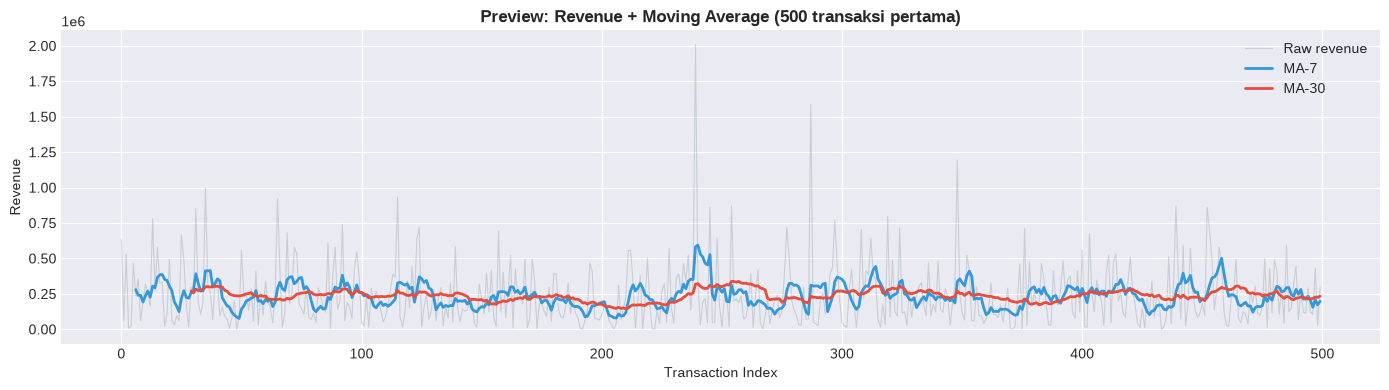

  ✅ Chart disimpan ke rolling_window_preview.png


In [28]:

# ================================================================
# CELL 9 — ROLLING WINDOW (TIME-SERIES)
# ================================================================
print('\n' + '='*65)
print('  📈 EXPERIMENT 9 — Rolling Window (Time-Series)')
print('='*65)
print('  Apa itu? Hitung statistik dari N baris terakhir secara bergerak')
print('  (sliding window). Contoh window=7: di baris ke-i, lihat baris')
print('  i-6 hingga i, hitung mean/std/min/max, geser ke i+1, dst.')
print('  Mengapa? Fondasi analisis time-series: moving average (smoothing'),
print('  tren), rolling std (deteksi volatilitas), rolling sum (total bergerak).')
print('  CATATAN: cuDF belum support rolling().agg([list]) — tiap agregasi')
print('  dijalankan terpisah lalu digabung ke DataFrame.\n')
print('  ⚠️  Wajib sort by timestamp dulu sebelum rolling!\n')
 
# Sort by timestamp (wajib untuk operasi time-series)
df_cpu_ts = df_cpu.sort_values('timestamp').reset_index(drop=True)
if GPU_AVAILABLE:
    df_gpu_ts = df_gpu.sort_values('timestamp').reset_index(drop=True)
 
# ── Rolling Window = 7 ──────────────────────────────────────────
print('  📌 Rolling window=7 (mean, std, min, max revenue):')
 
def rolling_w7_cpu():
    rev = df_cpu_ts['revenue']
    return pd.DataFrame({
        'mean': rev.rolling(7).mean(),
        'std' : rev.rolling(7).std(),
        'min' : rev.rolling(7).min(),
        'max' : rev.rolling(7).max(),
    })
 
cpu_rw7 = benchmark(rolling_w7_cpu, label='pandas rolling w=7  (CPU)')
 
if GPU_AVAILABLE:
    def rolling_w7_gpu():
        rev = df_gpu_ts['revenue']
        return cudf.DataFrame({
            'mean': rev.rolling(7).mean(),
            'std' : rev.rolling(7).std(),
            'min' : rev.rolling(7).min(),
            'max' : rev.rolling(7).max(),
        })
    gpu_rw7 = benchmark(rolling_w7_gpu, label='cuDF   rolling w=7  (GPU)')
    print_result('Rolling Window=7', cpu_rw7, gpu_rw7)
else:
    print_result('Rolling Window=7', cpu_rw7)
 
# ── Rolling Window = 30 ─────────────────────────────────────────
print('\n  📌 Rolling window=30 (moving average 30 transaksi terakhir):')
cpu_rw30 = benchmark(
    lambda: df_cpu_ts['revenue'].rolling(window=30).mean(),
    label='pandas rolling w=30 (CPU)'
)
if GPU_AVAILABLE:
    gpu_rw30 = benchmark(
        lambda: df_gpu_ts['revenue'].rolling(window=30).mean(),
        label='cuDF   rolling w=30 (GPU)'
    )
    print_result('Rolling Window=30', cpu_rw30, gpu_rw30)
else:
    print_result('Rolling Window=30', cpu_rw30)
 
# Plot moving average preview
print('\n  📊 Membuat chart moving average (500 transaksi pertama)...')
sample_ts = df_cpu_ts.head(500)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample_ts.index, sample_ts['revenue'], alpha=0.4, linewidth=0.8,
        label='Raw revenue', color='#95a5a6')
ax.plot(sample_ts.index, sample_ts['revenue'].rolling(7).mean(),
        linewidth=2, label='MA-7',  color='#3498db')
ax.plot(sample_ts.index, sample_ts['revenue'].rolling(30).mean(),
        linewidth=2, label='MA-30', color='#e74c3c')
ax.set_title('Preview: Revenue + Moving Average (500 transaksi pertama)', fontweight='bold')
ax.set_xlabel('Transaction Index')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.savefig('rolling_window_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✅ Chart disimpan ke rolling_window_preview.png')
 

---
## 🏗️ Cell 10 — End-to-End Pipeline

**Apa itu?** Simulasi alur kerja analytics lengkap: filter → feature engineering → join → aggregasi → sort.  
**Mengapa?** Benchmark per-operasi bisa menyesatkan — di produksi kita tidak pernah hanya menjalankan satu operasi. Pipeline lengkap mengungkap apakah keunggulan GPU di setiap langkah **terakumulasi** atau **terdilusi** karena bottleneck di satu tahap. Ini ukuran paling realistis dari nilai GPU di dunia nyata.

In [23]:
# ================================================================
# CELL 10 — End-to-End Pipeline
# ================================================================
print('🏗️ EXPERIMENT 10 — End-to-End Pipeline')
print('   Tahap: Filter → Feature Eng → Join → GroupBy → Sort\n')

def full_pipeline(df, products):
    # Tahap 1: Filter hanya transaksi completed
    df = df[df['status'] == 'completed'].copy()

    # Tahap 2: Feature engineering
    df['net_revenue']   = df['revenue'] * (1 - df['discount_pct']) - df['shipping_cost']
    df['profit_margin'] = (df['net_revenue'] / df['revenue']).clip(0, 1)
    df['is_high_value'] = (df['net_revenue'] > 500_000).astype(int)
    df['gross_profit']  = df['revenue'] - df['cost_price'] - df['shipping_cost']

    # Tahap 3: Join dengan tabel produk
    df = df.merge(products[['product_id', 'msrp']], on='product_id', how='left')

    # Tahap 4: GroupBy aggregation
    summary = df.groupby(['category', 'region']).agg(
        total_net_revenue  = ('net_revenue',   'sum'),
        avg_margin         = ('profit_margin', 'mean'),
        high_value_count   = ('is_high_value', 'sum'),
        total_transactions = ('transaction_id','count'),
        avg_rating         = ('rating',        'mean')
    ).reset_index()

    # Tahap 5: Sort
    return summary.sort_values('total_net_revenue', ascending=False)

cpu_pipe = benchmark(lambda: full_pipeline(df_cpu, products_cpu), label='pandas full pipeline (CPU)')

if GPU_AVAILABLE:
    gpu_pipe = benchmark(lambda: full_pipeline(df_gpu, products_gpu), label='cuDF   full pipeline (GPU)')
    print_result('Full Pipeline', cpu_pipe, gpu_pipe)

    print('\n  Top 5 hasil pipeline (GPU):')
    display(full_pipeline(df_gpu, products_gpu).head(5).to_pandas())
else:
    print_result('Full Pipeline', cpu_pipe)
    print('\n  Top 5 hasil pipeline (CPU):')
    display(full_pipeline(df_cpu, products_cpu).head(5))

🏗️ EXPERIMENT 10 — End-to-End Pipeline
   Tahap: Filter → Feature Eng → Join → GroupBy → Sort

  pandas full pipeline (CPU)                 → 0.4891s ± 0.0173s
  cuDF   full pipeline (GPU)                 → 0.0830s ± 0.0381s

  ──────────────────────────────────────────────────────────
  📌 Full Pipeline
  ──────────────────────────────────────────────────────────
  CPU (pandas) : 0.4891 detik
  GPU (cuDF)   : 0.0830 detik
  Speedup      : 5.9x  🚀
  ──────────────────────────────────────────────────────────

  Top 5 hasil pipeline (GPU):


,category,region,total_net_revenue,avg_margin,high_value_count,total_transactions,avg_rating
1,Home,Semarang,3.454933e+09,0.632410,2423,11000,3.761909
17,Electronics,Makassar,2.562325e+09,0.587108,1739,11000,3.739455
68,Food,Bali,2.396295e+09,0.553717,1202,11000,3.745636
55,Travel,Surabaya,2.385776e+09,0.504274,1359,9000,3.769333
92,Books,Semarang,2.217633e+09,0.597261,1328,9000,3.755778


---
## 📊 Cell 11 — Visualisasi & Load Test Grafik

**Apa itu Load Test Grafik?** Mengukur kecepatan **merender** visualisasi dari data besar.  
**Mengapa?** Sering terjadi GPU sudah sangat cepat memproses data, tapi rendering chart-nya (via matplotlib, berjalan di CPU) justru menjadi bottleneck baru. Load test grafik menemukan batas kapasitas rendering dan membantu memutuskan kapan harus pra-agregasi sebelum plotting.

📊 Membuat chart ringkasan benchmark...

  Operasi yang akan diplot: 15
   1. Read CSV               CPU=1.5060s  GPU=0.0824s  Speedup=18.3x
   2. Read Parquet           CPU=0.5474s  GPU=0.0397s  Speedup=13.8x
   3. Filter Single          CPU=0.0198s  GPU=0.0056s  Speedup=3.6x
   4. Filter Multi           CPU=0.0833s  GPU=0.0083s  Speedup=10.1x
   5. GroupBy Single         CPU=0.0456s  GPU=0.0028s  Speedup=16.3x
   6. GroupBy Multi          CPU=0.1519s  GPU=0.0055s  Speedup=27.9x
   7. Sort Single            CPU=0.2398s  GPU=0.0121s  Speedup=19.8x
   8. Sort Multi             CPU=0.5126s  GPU=0.0212s  Speedup=24.1x
   9. Inner Join             CPU=0.2855s  GPU=0.0147s  Speedup=19.5x
  10. Left Join              CPU=0.2881s  GPU=0.0162s  Speedup=17.8x
  11. Feature Engineering    CPU=0.2525s  GPU=0.0198s  Speedup=12.7x
  12. String Manipulation    CPU=0.2543s  GPU=0.0026s  Speedup=98.4x
  13. Rolling Window=7       CPU=0.0753s  GPU=0.0114s  Speedup=6.6x
  14. Rolling Window=30      CPU=0

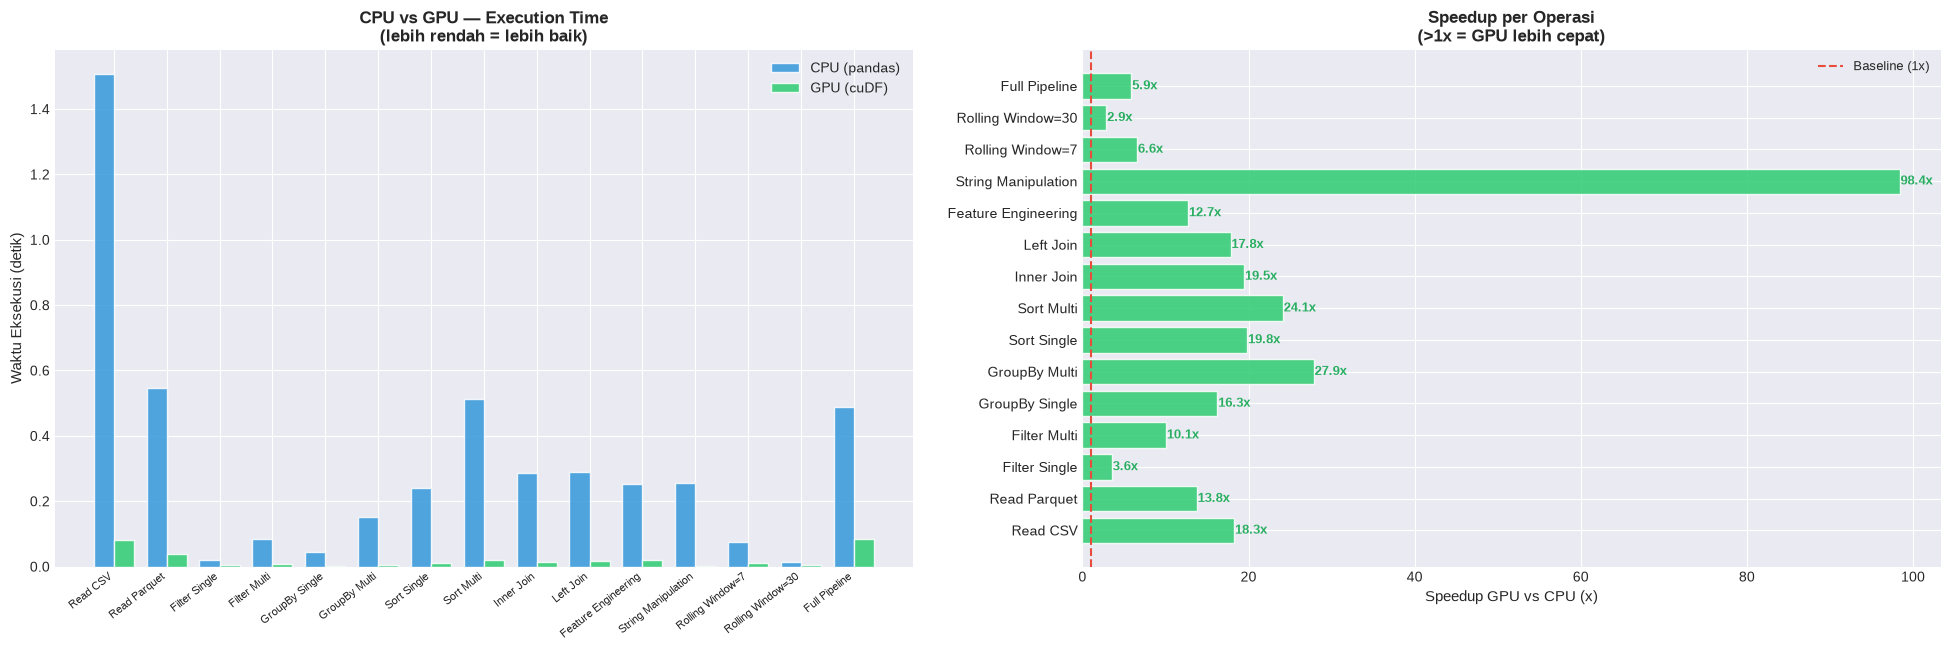

✅ Chart disimpan ke benchmark_results.png


In [29]:
# ================================================================
# CELL 11.1 — Chart: Ringkasan Benchmark CPU vs GPU
# ================================================================
print('📊 Membuat chart ringkasan benchmark...\n')

# Ambil data dari results dict (sudah diisi oleh print_result() di setiap experiment)
ops_order = [
    'Read CSV', 'Read Parquet',
    'Filter Single', 'Filter Multi',
    'GroupBy Single', 'GroupBy Multi',
    'Sort Single', 'Sort Multi',
    'Inner Join', 'Left Join',
    'Feature Engineering', 'String Manipulation',
    'Rolling Window=7', 'Rolling Window=30',
    'Full Pipeline',
]

labels, cpu_vals, gpu_vals, speedups = [], [], [], []
for op in ops_order:
    if op not in results:
        continue
    cpu_t = results[op].get('CPU')
    gpu_t = results[op].get('GPU')
    if cpu_t is None:
        continue
    labels.append(op)
    cpu_vals.append(cpu_t)
    gpu_vals.append(gpu_t if gpu_t is not None else 0)
    speedups.append(cpu_t / gpu_t if gpu_t else None)

print(f'  Operasi yang akan diplot: {len(labels)}')
for i, (l, c, g, s) in enumerate(zip(labels, cpu_vals, gpu_vals, speedups)):
    speedup_str = f'{s:.1f}x' if s else 'N/A'
    print(f'  {i+1:>2}. {l:<22} CPU={c:.4f}s  GPU={g:.4f}s  Speedup={speedup_str}')

has_gpu = any(v > 0 for v in gpu_vals)
n = len(labels)
x = np.arange(n)
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Bar: Execution Time ───────────────────────────────────────────
ax1 = axes[0]
ax1.bar(x - w/2, cpu_vals, w, label='CPU (pandas)', color='#3498db', alpha=0.85, edgecolor='white')
if has_gpu:
    ax1.bar(x + w/2, gpu_vals, w, label='GPU (cuDF)', color='#2ecc71', alpha=0.85, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=38, ha='right', fontsize=8)
ax1.set_ylabel('Waktu Eksekusi (detik)', fontsize=11)
ax1.set_title('CPU vs GPU — Execution Time\n(lebih rendah = lebih baik)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# ── Bar: Speedup ──────────────────────────────────────────────────
ax2 = axes[1]
valid = [(l, s) for l, s in zip(labels, speedups) if s is not None]
if valid:
    v_labels, v_speeds = zip(*valid)
    colors = ['#2ecc71' if s >= 1 else '#e74c3c' for s in v_speeds]
    bars = ax2.barh(v_labels, v_speeds, color=colors, alpha=0.85, edgecolor='white')
    ax2.axvline(x=1, color='#e74c3c', linestyle='--', linewidth=1.5, label='Baseline (1x)')
    for bar, val in zip(bars, v_speeds):
        ax2.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}x', va='center', fontsize=9, fontweight='bold',
                 color='#27ae60' if val >= 1 else '#c0392b')
    ax2.set_xlabel('Speedup GPU vs CPU (x)', fontsize=11)
    ax2.set_title('Speedup per Operasi\n(>1x = GPU lebih cepat)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, 'GPU tidak tersedia\nHanya CPU yang dijalankan',
             ha='center', va='center', transform=ax2.transAxes, fontsize=13)

plt.tight_layout(pad=2.5)
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart disimpan ke benchmark_results.png')

📏 Scalability Test: GroupBy pada berbagai ukuran data

    CPU    10,000 baris                      → 0.0016s ± 0.0001s
    GPU    10,000 baris                      → 0.0008s ± 0.0000s
  → Speedup    10,000 baris: 1.9x

    CPU    50,000 baris                      → 0.0037s ± 0.0001s
    GPU    50,000 baris                      → 0.0009s ± 0.0001s
  → Speedup    50,000 baris: 4.2x

    CPU   100,000 baris                      → 0.0047s ± 0.0000s
    GPU   100,000 baris                      → 0.0007s ± 0.0000s
  → Speedup   100,000 baris: 6.6x

    CPU   250,000 baris                      → 0.0124s ± 0.0012s
    GPU   250,000 baris                      → 0.0014s ± 0.0000s
  → Speedup   250,000 baris: 9.1x



    CPU   500,000 baris                      → 0.0236s ± 0.0028s
    GPU   500,000 baris                      → 0.0020s ± 0.0002s
  → Speedup   500,000 baris: 11.6x

    CPU 1,000,000 baris                      → 0.0456s ± 0.0049s
    GPU 1,000,000 baris                      → 0.0024s ± 0.0003s
  → Speedup 1,000,000 baris: 19.1x



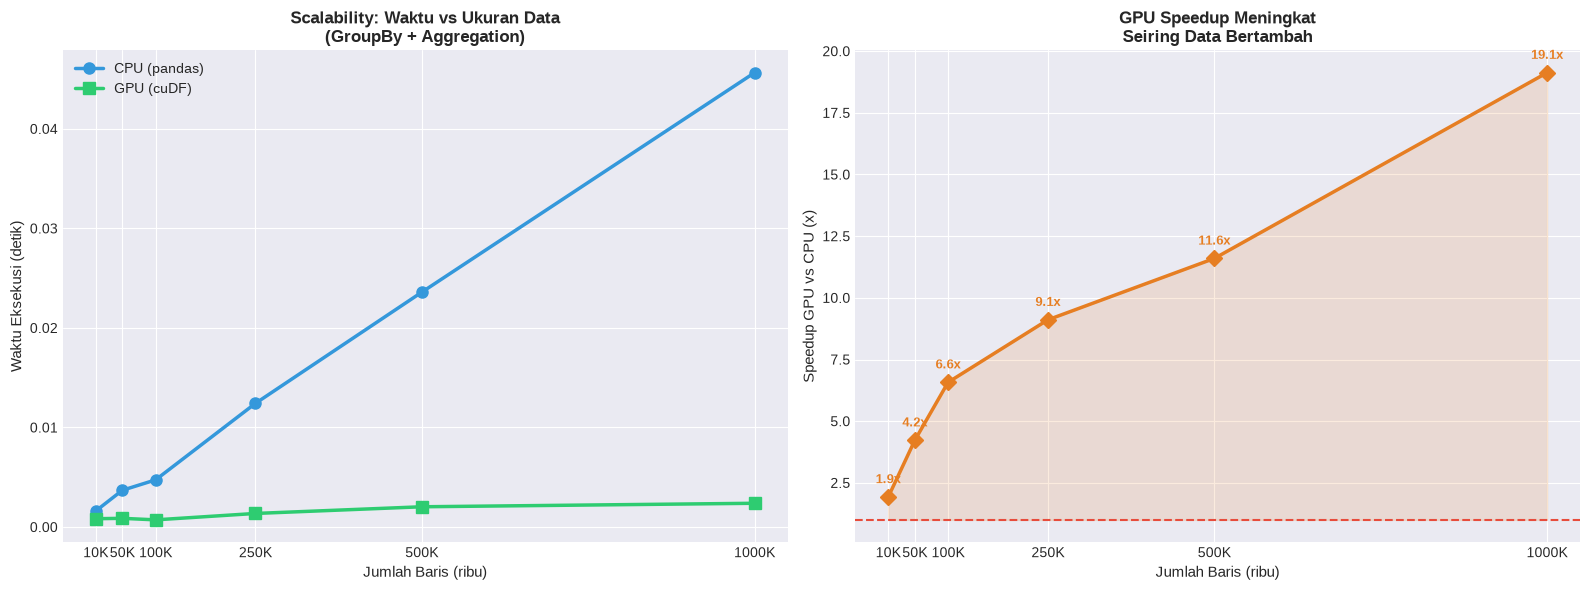

✅ Chart scalability disimpan ke scalability_results.png


In [30]:
# ================================================================
# CELL 11.2 — Scalability Test
# Membuktikan: GPU makin menguntungkan seiring data bertambah besar.
# Pada data kecil GPU bisa kalah karena overhead transfer.
# ================================================================
print('📏 Scalability Test: GroupBy pada berbagai ukuran data\n')

test_sizes = [10_000, 50_000, 100_000, 250_000, 500_000, min(1_000_000, len(df_cpu))]
test_sizes = sorted(set(test_sizes))

scale_cpu, scale_gpu, scale_speedup = [], [], []

for n in test_sizes:
    sub_cpu = df_cpu.head(n)
    t_cpu = benchmark(
        lambda: sub_cpu.groupby('category').agg({'revenue': 'sum', 'quantity': 'mean'}),
        n=3, label=f'  CPU {n:>9,} baris'
    )
    scale_cpu.append(t_cpu)

    if GPU_AVAILABLE:
        sub_gpu = df_gpu.head(n)
        t_gpu = benchmark(
            lambda: sub_gpu.groupby('category').agg({'revenue': 'sum', 'quantity': 'mean'}),
            n=3, label=f'  GPU {n:>9,} baris'
        )
        scale_gpu.append(t_gpu)
        scale_speedup.append(t_cpu / t_gpu)
        print(f'  → Speedup {n:>9,} baris: {t_cpu/t_gpu:.1f}x\n')
    else:
        print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sizes_k = [s / 1_000 for s in test_sizes]

axes[0].plot(sizes_k, scale_cpu, 'o-', color='#3498db', linewidth=2.5, markersize=8, label='CPU (pandas)')
if GPU_AVAILABLE:
    axes[0].plot(sizes_k, scale_gpu, 's-', color='#2ecc71', linewidth=2.5, markersize=8, label='GPU (cuDF)')
axes[0].set_xlabel('Jumlah Baris (ribu)', fontsize=11)
axes[0].set_ylabel('Waktu Eksekusi (detik)', fontsize=11)
axes[0].set_title('Scalability: Waktu vs Ukuran Data\n(GroupBy + Aggregation)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(sizes_k)
axes[0].set_xticklabels([f'{s:.0f}K' for s in sizes_k])

if GPU_AVAILABLE:
    axes[1].plot(sizes_k, scale_speedup, 'D-', color='#e67e22', linewidth=2.5, markersize=8)
    axes[1].fill_between(sizes_k, 1, scale_speedup, alpha=0.15, color='#e67e22')
    axes[1].axhline(y=1, color='#e74c3c', linestyle='--', linewidth=1.5, label='Baseline CPU')
    axes[1].set_xlabel('Jumlah Baris (ribu)', fontsize=11)
    axes[1].set_ylabel('Speedup GPU vs CPU (x)', fontsize=11)
    axes[1].set_title('GPU Speedup Meningkat\nSeiring Data Bertambah', fontsize=12, fontweight='bold')
    axes[1].set_xticks(sizes_k)
    axes[1].set_xticklabels([f'{s:.0f}K' for s in sizes_k])
    for x_val, y_val in zip(sizes_k, scale_speedup):
        axes[1].annotate(f'{y_val:.1f}x', (x_val, y_val),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, fontweight='bold', color='#e67e22')
else:
    axes[1].text(0.5, 0.5, 'GPU tidak tersedia', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13)

plt.tight_layout()
plt.savefig('scalability_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart scalability disimpan ke scalability_results.png')

🖼️  Load Test Grafik: Render Time vs Jumlah Titik Data

     10,000 titik → 0.008s  ✅
    100,000 titik → 0.011s  ✅
  1,000,000 titik → 0.035s  ✅


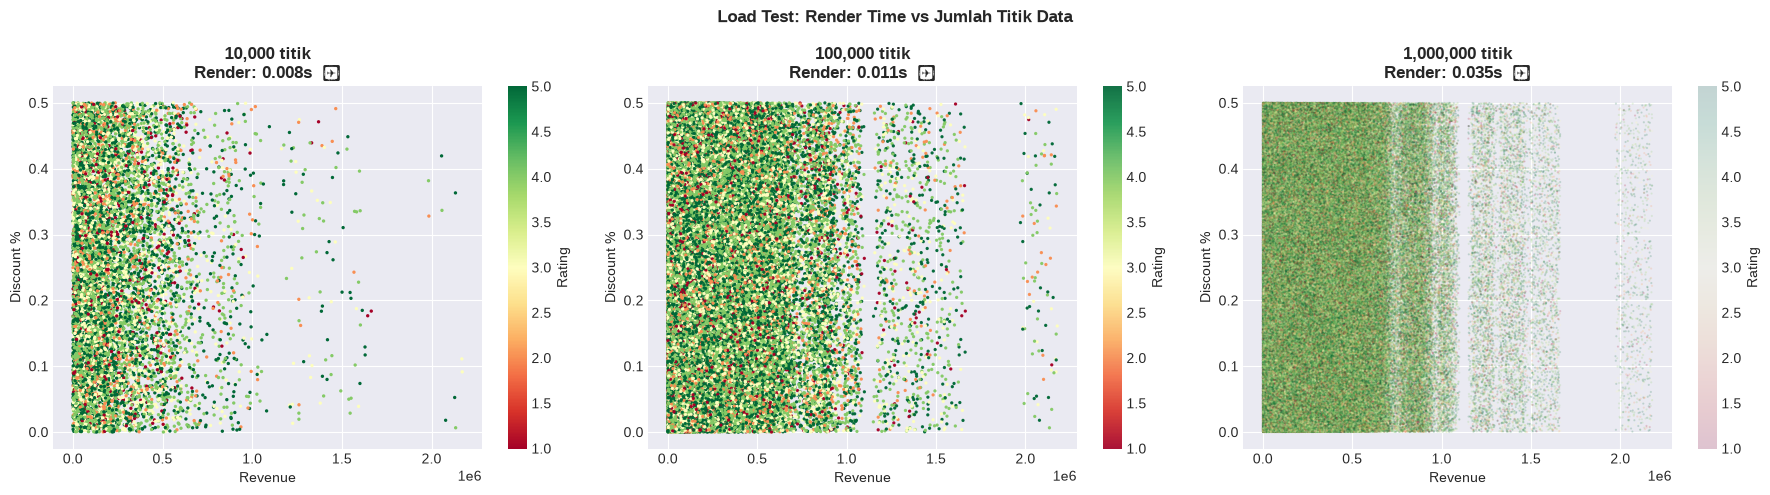


📌 Kesimpulan Load Test:
      10,000 titik → 0.008s → Cepat — aman untuk plotting langsung
     100,000 titik → 0.011s → Cepat — aman untuk plotting langsung
   1,000,000 titik → 0.035s → Cepat — aman untuk plotting langsung

💡 Tips: Plot hasil groupby (ratusan baris) bukan raw data (jutaan baris)
✅ Load test disimpan ke load_test_render.png


In [31]:
# ================================================================
# CELL 11.3 — Load Test Grafik
# Mencari titik di mana rendering chart mulai menjadi bottleneck.
# ================================================================
print('🖼️  Load Test Grafik: Render Time vs Jumlah Titik Data\n')

n_points_list = [10_000, 100_000, min(1_000_000, len(df_cpu))]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
render_times = {}

for idx, n_pts in enumerate(n_points_list):
    sample = df_cpu.sample(n_pts, random_state=42)

    t0 = time.perf_counter()
    sc = axes[idx].scatter(
        sample['revenue'],
        sample['discount_pct'],
        c=sample['rating'],
        cmap='RdYlGn',
        alpha=max(0.05, 1 - n_pts / 1_200_000),
        s=max(0.3, 2 - n_pts / 600_000)
    )
    plt.colorbar(sc, ax=axes[idx], label='Rating')
    t_render = time.perf_counter() - t0
    render_times[n_pts] = t_render

    status = '✅' if t_render < 1 else ('⚠️' if t_render < 5 else '❌')
    axes[idx].set_title(f'{n_pts:,} titik\nRender: {t_render:.3f}s  {status}', fontweight='bold')
    axes[idx].set_xlabel('Revenue')
    axes[idx].set_ylabel('Discount %')
    print(f'  {n_pts:>9,} titik → {t_render:.3f}s  {status}')

plt.suptitle('Load Test: Render Time vs Jumlah Titik Data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('load_test_render.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📌 Kesimpulan Load Test:')
for n, t in render_times.items():
    if t < 1:
        msg = 'Cepat — aman untuk plotting langsung'
    elif t < 5:
        msg = 'Mulai lambat — pertimbangkan sampling'
    else:
        msg = 'Terlalu lambat — gunakan pra-agregasi sebelum plot'
    print(f'   {n:>9,} titik → {t:.3f}s → {msg}')

print('\n💡 Tips: Plot hasil groupby (ratusan baris) bukan raw data (jutaan baris)')
print('✅ Load test disimpan ke load_test_render.png')

---
## 🏆 Cell 12 — Ringkasan & Kesimpulan

In [32]:
# ================================================================
# CELL 12.1 — Tabel ringkasan semua hasil
# ================================================================
print('=' * 65)
print('  🏆 RINGKASAN BENCHMARK — GPU vs CPU')
print('=' * 65)
print(f'  {"Operasi":<25} {"CPU (s)":>10} {"GPU (s)":>10} {"Speedup":>10}')
print('─' * 65)

summary_rows = []
for op, times in results.items():
    cpu_t = times.get('CPU')
    gpu_t = times.get('GPU')
    if cpu_t is None:
        continue
    if gpu_t is not None:
        speedup = cpu_t / gpu_t
        icon    = '🚀' if speedup > 5 else ('✅' if speedup > 1 else '🐢')
        print(f'  {op:<25} {cpu_t:>10.4f} {gpu_t:>10.4f} {speedup:>8.1f}x  {icon}')
    else:
        print(f'  {op:<25} {cpu_t:>10.4f} {"N/A":>10} {"N/A":>10}')
        speedup = None
    summary_rows.append({'Operasi': op, 'CPU (s)': cpu_t, 'GPU (s)': gpu_t, 'Speedup': speedup})

print('=' * 65)

# DataFrame summary
df_summary = pd.DataFrame(summary_rows)

if GPU_AVAILABLE and df_summary['Speedup'].notna().any():
    avg_spd  = df_summary['Speedup'].mean()
    best     = df_summary.loc[df_summary['Speedup'].idxmax()]
    worst    = df_summary.loc[df_summary['Speedup'].idxmin()]
    print(f'\n  📊 Rata-rata speedup    : {avg_spd:.1f}x')
    print(f'  🏆 Operasi terbaik GPU  : {best["Operasi"]} ({best["Speedup"]:.1f}x)')
    print(f'  ⚠️  Operasi terlemah GPU : {worst["Operasi"]} ({worst["Speedup"]:.1f}x)')

  🏆 RINGKASAN BENCHMARK — GPU vs CPU
  Operasi                      CPU (s)    GPU (s)    Speedup
─────────────────────────────────────────────────────────────────
  Read CSV                      1.5060     0.0824     18.3x  🚀
  Read Parquet                  0.5474     0.0397     13.8x  🚀
  Filter Single                 0.0198     0.0056      3.6x  ✅
  Filter Multi                  0.0833     0.0083     10.1x  🚀
  GroupBy Single                0.0456     0.0028     16.3x  🚀
  GroupBy Multi                 0.1519     0.0055     27.9x  🚀
  Sort Single                   0.2398     0.0121     19.8x  🚀
  Sort Multi                    0.5126     0.0212     24.1x  🚀
  Inner Join                    0.2855     0.0147     19.5x  🚀
  Left Join                     0.2881     0.0162     17.8x  🚀
  Feature Engineering           0.2525     0.0198     12.7x  🚀
  String Contains               0.1800     0.0060     30.0x  🚀
  String Manipulation           0.2543     0.0026     98.4x  🚀
  Full Pipeline  

In [33]:
# ================================================================
# CELL 12.2 — Kesimpulan & best practices
# ================================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║                    💡 KESIMPULAN                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ GPU UNGGUL di:                                           ║
║     • GroupBy + Aggregation  → hash grouping paralel        ║
║     • Vectorized computation → kalkulasi kolom masif        ║
║     • Join / Merge           → hash join paralel            ║
║     • Filter / Selection     → boolean masking paralel      ║
║     • Sort                   → parallel radix sort         ║
║     • Read CSV/Parquet       → parser paralel cuDF          ║
║                                                              ║
║  ⚠️  GPU KURANG UNGGUL di:                                   ║
║     • Data kecil (<100K)     → overhead transfer CPU↔GPU    ║
║     • String operations      → panjang variabel, sulit para ║
║     • apply() row-wise       → tidak bisa diparalelkan      ║
║     • Operasi sequential     → harus serial, 1 per 1       ║
║                                                              ║
║  💡 TIPS PRODUKSI:                                           ║
║     • Gunakan Parquet bukan CSV — lebih cepat & lebih kecil ║
║     • Pertahankan data di GPU selama pipeline berlangsung   ║
║     • Ganti apply() dengan vectorized ops                   ║
║     • Plot groupby result, bukan raw data jutaan baris      ║
║     • Gunakan Dask-cuDF jika data > VRAM                    ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                    💡 KESIMPULAN                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ GPU UNGGUL di:                                           ║
║     • GroupBy + Aggregation  → hash grouping paralel        ║
║     • Vectorized computation → kalkulasi kolom masif        ║
║     • Join / Merge           → hash join paralel            ║
║     • Filter / Selection     → boolean masking paralel      ║
║     • Sort                   → parallel radix sort         ║
║     • Read CSV/Parquet       → parser paralel cuDF          ║
║                                                              ║
║  ⚠️  GPU KURANG UNGGUL di:                                   ║
║     • Data kecil (<100K)     → overhead transfer CPU↔GPU    ║
║     • String operations      → panjang variabel, sulit para ║
║     • apply() row-wise       → tid

In [34]:
# ================================================================
# CELL 12.3 — Export hasil ke CSV
# ================================================================
df_summary.to_csv('benchmark_summary.csv', index=False)
print('✅ Semua hasil tersimpan:')
print('   📄 benchmark_summary.csv    → tabel angka hasil benchmark')
print('   🖼️  benchmark_results.png   → chart CPU vs GPU per operasi')
print('   🖼️  scalability_results.png → chart speedup vs ukuran data')
print('   🖼️  load_test_render.png    → chart render time grafik')
display(df_summary)

✅ Semua hasil tersimpan:
   📄 benchmark_summary.csv    → tabel angka hasil benchmark
   🖼️  benchmark_results.png   → chart CPU vs GPU per operasi
   🖼️  scalability_results.png → chart speedup vs ukuran data
   🖼️  load_test_render.png    → chart render time grafik


,Operasi,CPU (s),GPU (s),Speedup
0,Read CSV,1.505985,0.082409,18.274424
1,Read Parquet,0.547403,0.039724,13.780269
2,Filter Single,0.019754,0.005559,3.553541
3,Filter Multi,0.083250,0.008268,10.068514
4,GroupBy Single,0.045580,0.002804,16.255463
5,GroupBy Multi,0.151927,0.005453,27.862371
6,Sort Single,0.239814,0.012085,19.843792
7,Sort Multi,0.512630,0.021236,24.139555
8,Inner Join,0.285471,0.014661,19.471952
9,Left Join,0.288140,0.016152,17.838923
